In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os


In [2]:
normform = np.zeros(512)
normform[100:500] = 1.0

overall power increase: 5.737922850106262 dB


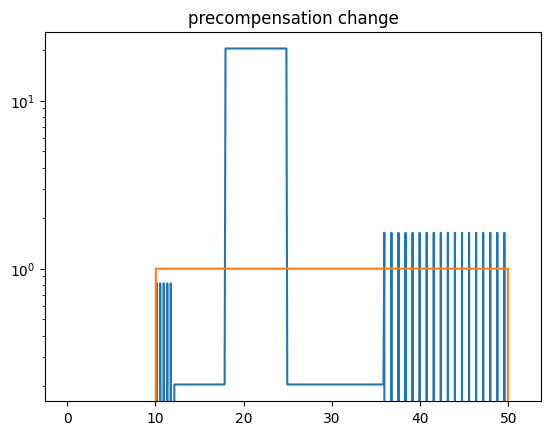

In [3]:
# load precompensation and noise
x=np.loadtxt('precompensation_change.txt')
#they applied precompensation change shifted by 1 bin
altform = np.zeros(512)
altform[89:89+len(x)] = x[:,3] ## NOTE it should really be 90, but they applied it shifted by 1 bin
altform*=normform # zero outside the tones we have
plt.title('precompensation change')
freq = 0.025 * (2+np.arange(512)*4)
plt.plot(freq, altform)
plt.plot(freq, normform)
plt.semilogy()
np.savetxt('implemented_precompensation.txt', np.column_stack((freq, altform/(normform+1e-100))))
print ("overall power increase:", 10*np.log10(altform.sum()/normform.sum()),'dB')

In [4]:
# for simulation, we create list of tones with complex amplitudes
wave = np.fromfile("../waveforms/calibrator_231001.bin", dtype=np.int16)
coeff = np.fft.rfft(wave)[1::2] ## only odd ones, i.e. 50kHz and above
coeff /= np.abs(coeff) ## normalize to 1
assert(np.allclose(np.abs(coeff),1))
## first the standard waveforms
with open("cal_coeff.dat","w") as f:
    for f_val,c in zip (freq, coeff*normform):
        if np.abs(c)>1e-6:
            f.write(f"{f_val:.3f} {c.real:.6f} {c.imag:.6f}\n")
## then the precompensation change waveforms
with open("cal_coeff_alt.dat","w") as f:
    for f_val,c in zip (freq, coeff*altform):
        if np.abs(c)>1e-6:
            f.write(f"{f_val:.3f} {c.real:.6f} {c.imag:.6f}\n")

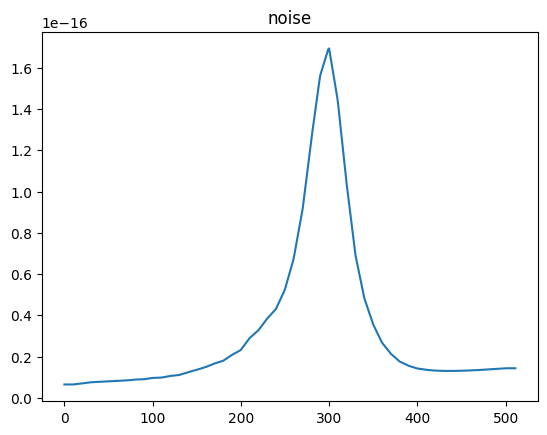

In [5]:
freq, noise = np.loadtxt('noise.txt').T
plt.figure()
#plt.plot(freq,noise)
plt.title('noise')
noise = np.interp(np.arange(512)*0.1+0.025, freq, noise)
# create weights
plt.plot(noise)

In [6]:

#now creates these final weights
wlist = []
# 0 just the bright part
weights = np.copy(altform)
weights[weights<10]=0.0
wlist.append(weights*noise)
# 1 altform full range, but bigger than 0.5
weights = np.copy(altform)
weights[weights<0.5]=0.0
wlist.append(weights*noise)
# 2 altform full range
weights = np.copy(altform)
wlist.append(weights*noise)
# 3 normform full range
weights = np.copy(normform)
wlist.append(weights*noise)
# 4 normform around bright part
weights = np.copy(normform)
weights[noise<0.5e-16]=0.0
wlist.append(weights*noise)
# 5 normform less stringent cut
weights = np.copy(normform)
weights[noise<0.2e-16]=0.0
wlist.append(weights*noise) 
# 6 high freq part (testing, sans noise weighting)
weights = np.copy(normform)
weights[:450]=0.0
wlist.append(weights)
# 7 med freq part
weights = np.copy(normform)
weights[:200]=0.0
weights[450:]=0.0
wlist.append(weights)
# 8 low freq part
weights = np.copy(normform)
weights[200:]=0.0
wlist.append(weights)



In [7]:
#normalize weights
weights = [(w/w.max()*255).astype(int) for w in wlist]

In [8]:
assert(np.where(weights[2]>0)[0][0]==101)  # lowest tone at 10.15MHz
assert(np.where(weights[2]>0)[0][-1]==495)  # highest tone at 49.55MHz
assert(np.where(weights[3]>0)[0][0]==100)  # lowest tone at 10.05MHz
assert(np.where(weights[3]>0)[0][-1]==499)  # highest tone at 49.95MHz


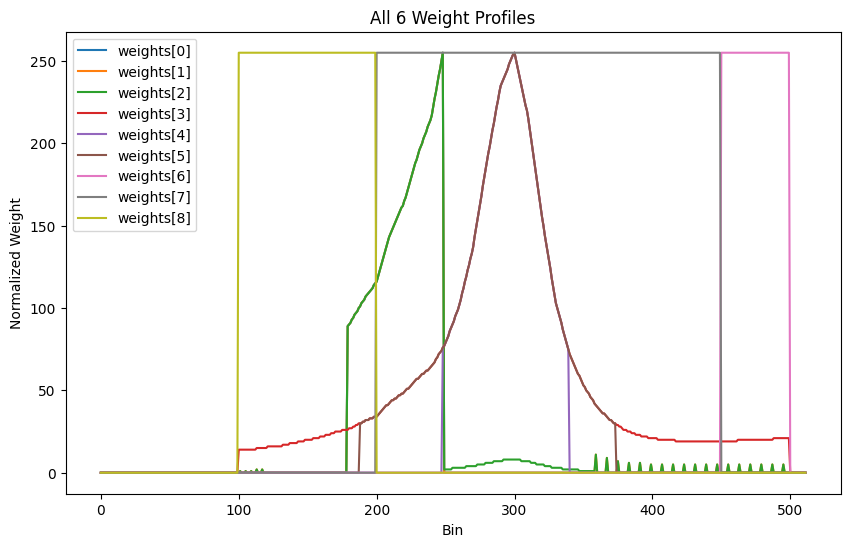

In [9]:
plt.figure(figsize=(10,6))
for i, w in enumerate(weights):
    plt.plot(w, label=f'weights[{i}]')
plt.title('All 6 Weight Profiles')
plt.xlabel('Bin')
plt.ylabel('Normalized Weight')
plt.legend()
plt.show()

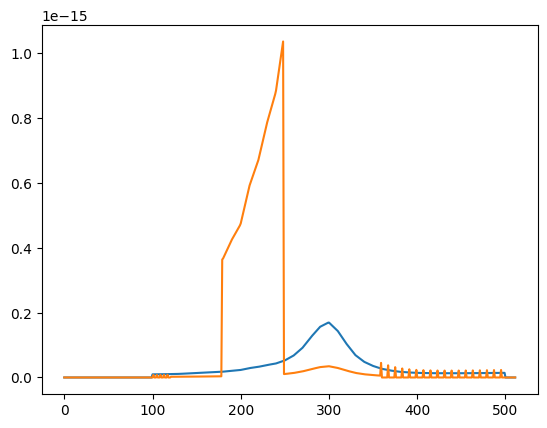

In [10]:
plt.plot(normform*noise)
plt.plot(altform*noise)

In [11]:
# now let's export
os.makedirs('cal_weights', exist_ok=True)
for i, w in enumerate(weights):
    np.savetxt(f'cal_weights/{i}.dat', w, fmt='%3i')